# Figure 2: Spectral Parameter Conflations

Note: this is adapted from [this page](https://fooof-tools.github.io/fooof/auto_motivations/measurements/plot_PeriodicAperiodicFeatures.html).

In [32]:
import matplotlib.pyplot as plt

from fooof import Bands
from fooof.utils import trim_spectrum
from fooof.sim.gen import gen_power_spectrum
from fooof.plts.spectra import plot_spectra_shading
from neurodsp.utils import set_random_seed

In [33]:
import seaborn as sns
sns.set_context('poster')

In [34]:
set_random_seed(505)

## Settings

In [36]:
f_range = [2, 30]

In [30]:
alpha_col = '#1882d9'

## Spectral Parameters

In [24]:
# Simulation Settings
nlv = 0
f_res = 0.1
f_range = [3, 35]

# Define baseline parameter values
ap_base = [0, 1.5]
pe_base = [[10, 0.5, 1], [22, 0.2, 2]]

# Define parameters sets with changes in each parameter
pw_diff = [[10, 0.311, 1], [22, 0.2, 2]]
cf_diff = [[11.75, 0.5, 1], [22, 0.2, 2]]
off_diff = [-0.126, 1.5]
exp_diff = [-0.87, 0.75]

In [25]:
# Create baseline power spectrum, to compare to
freqs, powers_base = gen_power_spectrum(f_range, ap_base, pe_base, nlv, f_res)

In [26]:
# Create comparison power spectra, with differences in different parameters of the data
_, powers_pw = gen_power_spectrum(f_range, ap_base, pw_diff, nlv, f_res)
_, powers_cf = gen_power_spectrum(f_range, ap_base, cf_diff, nlv, f_res)
_, powers_off = gen_power_spectrum(f_range, off_diff, pe_base, nlv, f_res)
_, powers_exp = gen_power_spectrum(f_range, exp_diff, pe_base, nlv, f_res)

In [27]:
# Collect the comparison power spectra together
all_powers = {
    'Alpha Power Change' : powers_pw,
    'Alpha Frequency Change' : powers_cf,
    'Offset Change' : powers_off,
    'Exponent Change' : powers_exp
}

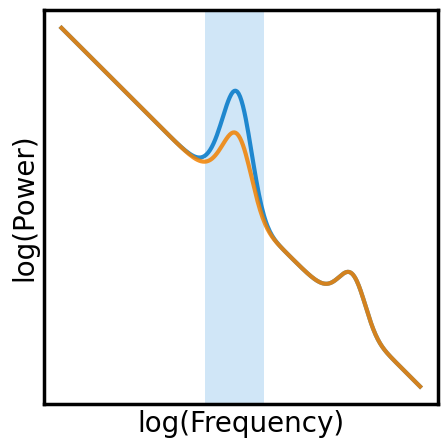

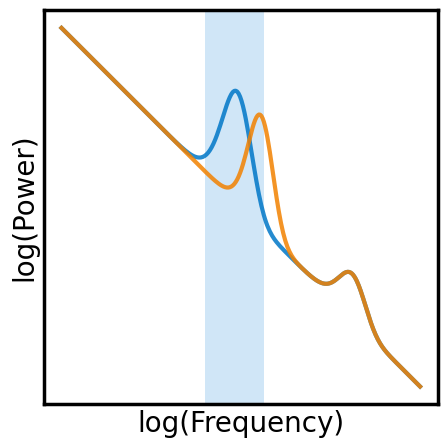

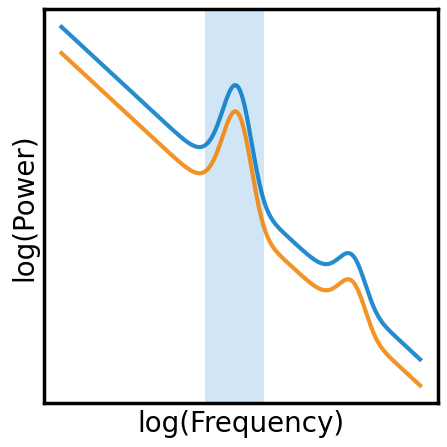

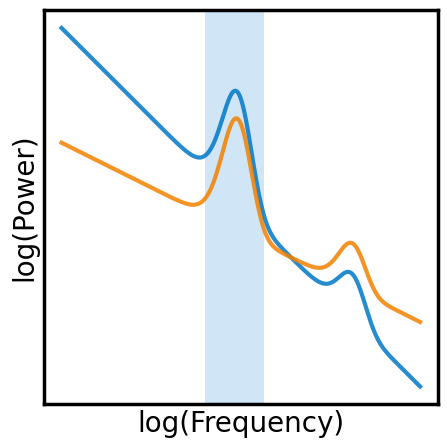

In [38]:
for ind, powers in enumerate(list(all_powers.values())):
    _, ax = plt.subplots(figsize=(5, 5))
    plot_spectra_shading(freqs, [powers_base, powers], 
                         [8, 12], shade_colors=alpha_col,
                         lw=3, alpha=0.85,
                         log_freqs=True, log_powers=True, ax=ax)
    
    colors = ['#0077c7', '#f28100']
    for line, color in zip(ax.get_lines(), colors):
        line.set_color(color)
    plt.xticks([]); plt.yticks([]);